In [2]:
import numpy as np
import h5py
import os 
from os import path
from matplotlib import pyplot as plt

In [3]:
output_files_path = "/home/itamarg/workspace/RICH/output/MarshakMultigroup_4"
path_to_initial_snap = path.join(output_files_path, f"snap_{0}.h5")

num_of_snaps = len([file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("snap")])

num_groups = 0
num_cells = 0

with h5py.File(path_to_initial_snap) as h5_file:
    num_cells = len(np.array(h5_file["Eg_0"]))
    num_groups = len([key for key in h5_file.keys() if "Eg" in key])
    print(h5_file.keys())

<KeysViewHDF5 ['Box', 'CMx', 'CMy', 'CMz', 'Cycle', 'Density', 'Eg_0', 'Eg_1', 'Eg_10', 'Eg_11', 'Eg_12', 'Eg_13', 'Eg_14', 'Eg_15', 'Eg_16', 'Eg_17', 'Eg_18', 'Eg_19', 'Eg_2', 'Eg_20', 'Eg_21', 'Eg_22', 'Eg_23', 'Eg_24', 'Eg_25', 'Eg_26', 'Eg_27', 'Eg_28', 'Eg_29', 'Eg_3', 'Eg_4', 'Eg_5', 'Eg_6', 'Eg_7', 'Eg_8', 'Eg_9', 'Erad', 'ID', 'InternalEnergy', 'Pressure', 'Temperature', 'Time', 'Volume', 'Vx', 'Vy', 'Vz', 'X', 'Y', 'Z', 'stickers', 'tracers']>


In [8]:
speed_of_light = 2.99792458e10
stefan_boltzman = 5.670374e-5
radiation_constant = 4 * stefan_boltzman / speed_of_light
boltzmann_constant = 1.380649e-16


mscale = 2e33
lscale = 7e10
tscale = 1603

ev = 1.602176634e-12
kev = 1e3*ev

G=30
Emin = kev*1e-4
Emax = kev*1e2

energy_groups_boundary = np.geomspace(Emin, Emax, G+1)
energy_groups_boundary_kev = energy_groups_boundary / kev
energy_groups_width = np.diff(energy_groups_boundary, n=1)

In [12]:
Eg = np.ndarray(shape=(num_of_snaps, num_cells, num_groups))
Er = np.ndarray(shape=(num_of_snaps, num_cells))
Tm = np.ndarray(shape=(num_of_snaps, num_cells))

for i in range(num_of_snaps):
    path_to_snap = path.join(output_files_path, f"snap_{i}.h5")
    with h5py.File(path_to_snap) as h5_file:
        Tm[i, :] = np.array(h5_file["Temperature"])
        Er[i, :] = np.array(h5_file[f"Erad"])*np.array(h5_file["Density"]) * mscale / tscale**2 / lscale
        for g in range(num_groups):
            Eg[i, :, g] = np.array(h5_file[f"Eg_{g}"])*np.array(h5_file["Density"]) * mscale / tscale**2 / lscale

In [13]:
def planck_func(x):
    em = np.exp(-x)
    return 15.*x**3*em / (np.pi**4*(1.-em))

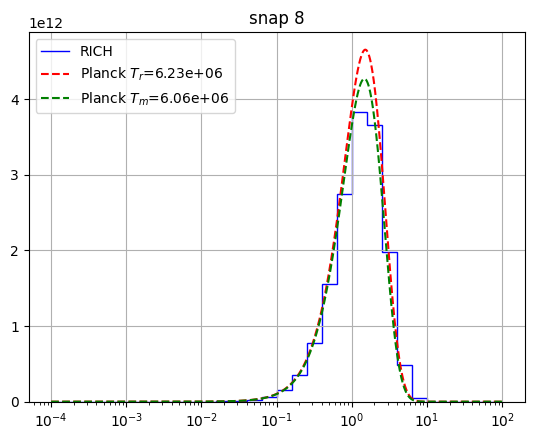

In [15]:
cell = 100
dir_figs = path.join(output_files_path, "spectrum", f"cell_{cell}")
os.makedirs(dir_figs, exist_ok=True)

for i in range(num_of_snaps):
    rad_spec_cell_kev = kev*Eg[i, cell, :] / (energy_groups_width)

    plt.stairs(edges=energy_groups_boundary/kev, values=rad_spec_cell_kev, color='b', linestyle="-", label="RICH")

    aTr4 = Er[i, cell] 
    Tr = (aTr4 / radiation_constant)**0.25
    kTr = boltzmann_constant*Tr
    ec_plot = np.geomspace(energy_groups_boundary[0], energy_groups_boundary[-1], 1000)
    
    plt.plot(ec_plot/kev, aTr4*planck_func(ec_plot/kTr)/(kTr/kev), "--r", label=f"Planck $T_{{r}}$={Tr:.2e}")

    aTm4 = radiation_constant*Tm[i, cell]**4
    kTm = boltzmann_constant*Tm[i, cell]
    plt.plot(ec_plot/kev, aTm4*planck_func(ec_plot/kTm)/(kTm/kev), "--g", label=f"Planck $T_{{m}}$={Tm[i, cell]:.2e}")


    plt.title(f"snap {i}")
    plt.xscale("log")
    plt.legend(loc="best")
    plt.grid()
    plt.savefig(path.join(dir_figs, f"snap_{i}.png"))
    if i == num_of_snaps - 1: plt.show()
    plt.close()
    